# Data Exploration
This notebook explores the **raw** dataset first (to diagnose issues), then the **cleaned** dataset (to verify `load_clean_data()` fixed everything as intended).

In [50]:
# Import shared cleaning/loading functions from utils.py
from utils import load_raw_data
from utils import load_clean_data

import pandas as pd
# Disable scientific notation in pandas output, show plain comma-separated numbers instead
# (e.g. 21,270.82 instead of 2.127082e+04)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

import matplotlib.pyplot as plt  # for plotting
import seaborn as sns            # for heatmaps and boxplots


## Raw Data Exploration
Investigating the dataset in its original, untouched state — no cleaning applied yet. This tells us what `load_clean_data()` in `utils.py` needs to fix.

In [51]:
# Load the RAW, unmodified dataset (not the cleaned version)
# We want to see the data exactly as it exists before any fixes are applied
df_raw = load_raw_data("data.csv")


In [52]:
# Print number of rows and columns as a basic sanity check
print(f"Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")


Shape: 80765 rows, 18 columns


In [53]:
# Show the first few rows to visually confirm the data loaded as expected
df_raw.head()


,training_date,id,reg_year,plate_age_id,year_plate_start_date,mileage,advertised_price,at_derivative_id,make,model,generation,fuel,engine,body,transmission,trim,doors,list_price
0,2023-06-01,e79c9066f50e136b5ab14bb39996a62b,2009,9,2009-03-01,83000,5290,ff04b6482e3e4eaf9af497526d99f874,Mercedes-Benz,SLK,Convertible (2008 - 2011),Petrol,1.80,Convertible,Automatic,NaN,2,"31,986.00"
1,2023-06-01,3314e91aaa6e5d8adfec7266ae7f9ece,2009,9,2009-03-01,85900,9500,cb37d7493efd45b4a172b20258b3d323,BMW,X5,SUV (2006 - 2014),Diesel,3.00,SUV,Automatic,M Sport,5,"48,444.00"
2,2023-06-01,36350752d23f19eb8eb3d3f545b2633f,2009,9,2009-03-01,114000,4490,85e0026201a141d4b68d07dfd1fe2141,Volvo,XC70,Estate (2007 - 2013) MK 2,Diesel,2.40,Estate,Manual,SE,5,"30,146.00"
3,2023-06-01,dada9107064ba35a5570b939d2861f97,2009,9,2009-03-01,24900,3829,8f1339f38bab4f0aa8f194963e38e905,Suzuki,Alto,Hatchback (2009 - 2015) MK 6,Petrol,1.00,Hatchback,Manual,SZ3,5,"7,891.00"
4,2023-06-01,32d056600b4346d9ddd96775fb6cf926,2009,9,2009-03-01,99000,2995,22be473a397e4641a3ba52ea1d4be819,Mazda,Mazda3,Hatchback (2009 - 2013),Petrol,1.60,Hatchback,Manual,Sport,5,"17,370.00"


In [54]:
# Check the data type pandas assigned to each column
# int64/float64 = numeric, object = text/string (or a numeric column that failed to parse)
df_raw.dtypes


training_date                str
id                           str
reg_year                   int64
plate_age_id               int64
year_plate_start_date        str
mileage                    int64
advertised_price           int64
at_derivative_id             str
make                         str
model                        str
generation                   str
fuel                         str
engine                   float64
body                         str
transmission                 str
trim                         str
doors                      int64
list_price               float64
dtype: object

In [55]:
# Count missing values per column
missing = df_raw.isnull().sum()

# Convert to percentage of total rows, easier to judge severity at a glance
missing_pct = (missing / len(df_raw)) * 100

# Combine into one table, sorted worst-first
missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct.round(2)
}).sort_values("missing_pct", ascending=False)

missing_summary


,missing_count,missing_pct
engine,3281,4.06
trim,2521,3.12
id,0,0.00
training_date,0,0.00
reg_year,0,0.00
plate_age_id,0,0.00
advertised_price,0,0.00
at_derivative_id,0,0.00
year_plate_start_date,0,0.00
mileage,0,0.00


In [56]:
# List the categorical columns we'll eventually need to encode
categorical_cols = ["make", "model", "generation", "fuel", "engine", 
                     "body", "transmission", "trim", "plate_age_id", 
                     "at_derivative_id"]

# Print the number of DISTINCT values per categorical column
# This tells us cardinality - directly affects which encoders are viable per column
for col in categorical_cols:
    print(f"{col}: {df_raw[col].nunique()} unique values")


make: 63 unique values
model: 676 unique values
generation: 841 unique values
fuel: 8 unique values
engine: 54 unique values
body: 7 unique values
transmission: 2 unique values
trim: 1520 unique values
plate_age_id: 30 unique values
at_derivative_id: 19841 unique values


In [57]:
# For each categorical column, print the 15 most frequent values
# Helps spot inconsistent formatting (e.g. "Automatic" vs "automatic")
# or placeholder values hiding as a category (e.g. "Unknown", "-")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df_raw[col].value_counts().head(15))



--- make ---
make
Ford             7426
Audi             6806
BMW              6614
Volkswagen       6522
Mercedes-Benz    6190
Vauxhall         4999
Land Rover       3489
Toyota           3426
Nissan           3324
Kia              2977
Peugeot          2826
Hyundai          2398
MINI             2346
SKODA            2147
Volvo            1991
Name: count, dtype: int64

--- model ---
model
Fiesta      2538
Golf        2254
Focus       1897
Corsa       1594
A Class     1591
1 Series    1312
C Class     1293
3 Series    1290
Hatch       1263
Qashqai     1205
A3          1078
Polo        1035
500         1000
Juke         961
Sportage     957
Name: count, dtype: int64

--- generation ---
generation
SUV (2019 - )              3368
SUV (2017 - 2021)          2762
Hatchback (2019 - )        2252
Hatchback (2017 - 2020)    2219
Hatchback (2017 - 2021)    2150
SUV (2020 - )              2097
Hatchback (2020 - )        1992
SUV (2016 - 2020)          1883
SUV (2018 - )              1862
Hatc

In [58]:
# Specifically check whether "engine" is missing ONLY for electric vehicles
# (as the schema suggested - engine size isn't applicable to EVs)
# This confirms whether the missingness is structural/explainable rather than random
df_raw.groupby("fuel")["engine"].apply(lambda x: x.isnull().sum())


fuel
Bi Fuel                     0
Diesel                      0
Diesel Hybrid               0
Diesel Plug-in Hybrid       0
Electric                 3220
Petrol                      0
Petrol Hybrid               0
Petrol Plug-in Hybrid      61
Name: engine, dtype: int64

In [59]:
# Summary statistics for the target variable (advertised_price)
# Useful for spotting obvious data errors (e.g. price of £0, or extreme outliers)
df_raw["advertised_price"].describe()


count      80,765.00
mean       21,270.82
std        22,805.72
min           695.00
25%        10,495.00
50%        16,990.00
75%        24,499.00
max     1,195,000.00
Name: advertised_price, dtype: float64

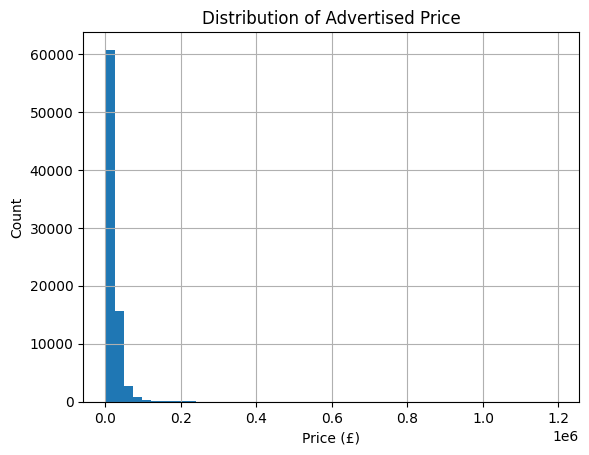

In [60]:
# Visualise the distribution of advertised_price
df_raw["advertised_price"].hist(bins=50)
plt.title("Distribution of Advertised Price")
plt.xlabel("Price (£)")
plt.ylabel("Count")
plt.show()


In [61]:
# Check for fully duplicated rows (every column identical across two or more rows)
# Real-world scraped/aggregated datasets often contain accidental duplicates
duplicate_count = df_raw.duplicated().sum()
print(f"Fully duplicate rows: {duplicate_count}")

# Also check duplicates on 'id' specifically, since each advert should have a unique id
# If this is non-zero, it suggests the same advert was recorded more than once
duplicate_ids = df_raw["id"].duplicated().sum()
print(f"Duplicate IDs: {duplicate_ids}")


Fully duplicate rows: 0
Duplicate IDs: 0


In [62]:
# Check the 'doors' column for unexpected values (e.g. a 0-door or 7+ door entry
# that looks like a data error rather than a real car configuration)
df_raw["doors"].value_counts().sort_index()


doors
0        3
2     4871
3     6308
4     5956
5    63417
6      210
Name: count, dtype: int64

In [63]:
# Sanity check the relationship between plate_age_id and year_plate_start_date.
# Since every plate code should correspond to exactly ONE start date, each
# plate_age_id should map to only 1 unique year_plate_start_date.
# If any plate_age_id shows more than 1, that's a data quality issue worth noting.
df_raw.groupby("plate_age_id")["year_plate_start_date"].nunique().sort_values(ascending=False).head()


plate_age_id
70    2
71    2
68    2
67    2
66    2
Name: year_plate_start_date, dtype: int64

## Clean Data Exploration
Verifying the **cleaned** dataset (produced by `load_clean_data()`) looks as expected. This is a before/after check, not new cleaning logic.

In [64]:
# Load the cleaned dataset (df_raw was already loaded above)
df_clean = load_clean_data("data.csv")

# Compare shapes: confirms how much data was removed by cleaning
print(f"Raw shape:   {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
print(f"Clean shape: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")
print(f"Rows removed: {df_raw.shape[0] - df_clean.shape[0]}")


Raw shape:   80765 rows, 18 columns
Clean shape: 79162 rows, 17 columns
Rows removed: 1603


In [65]:
# Visually sanity-check the cleaned data
df_clean.head()


,reg_year,plate_age_id,mileage,advertised_price,make,model,generation,fuel,engine,body,transmission,trim,doors,list_price,vehicle_age_days,vehicle_age_years,engine_missing
0,2009,9,83000,5290,Mercedes-Benz,SLK,Convertible (2008 - 2011),Petrol,1.80,Convertible,Automatic,Missing,2,"31,986.00",5205,14.25,0
1,2009,9,85900,9500,BMW,X5,SUV (2006 - 2014),Diesel,3.00,SUV,Automatic,M Sport,5,"48,444.00",5205,14.25,0
2,2009,9,114000,4490,Volvo,XC70,Estate (2007 - 2013) MK 2,Diesel,2.40,Estate,Manual,SE,5,"30,146.00",5205,14.25,0
3,2009,9,24900,3829,Suzuki,Alto,Hatchback (2009 - 2015) MK 6,Petrol,1.00,Hatchback,Manual,SZ3,5,"7,891.00",5205,14.25,0
4,2009,9,99000,2995,Mazda,Mazda3,Hatchback (2009 - 2013),Petrol,1.60,Hatchback,Manual,Sport,5,"17,370.00",5205,14.25,0


In [66]:
# Check column list and dtypes on the cleaned data
# Confirms dropped columns (training_date, year_plate_start_date, id, at_derivative_id)
# are gone, and new engineered columns (vehicle_age_days/years, engine_missing) are present
df_clean.dtypes


reg_year               int64
plate_age_id           int64
mileage                int64
advertised_price       int64
make                     str
model                    str
generation               str
fuel                     str
engine               float64
body                     str
transmission             str
trim                     str
doors                  int64
list_price           float64
vehicle_age_days       int64
vehicle_age_years    float64
engine_missing         int64
dtype: object

In [67]:
# Confirm there are NO missing values left anywhere in the cleaned dataset
# (every column should show 0 here; if any column shows non-zero, something in
# load_clean_data() didn't handle that column properly)
df_clean.isnull().sum()


reg_year             0
plate_age_id         0
mileage              0
advertised_price     0
make                 0
model                0
generation           0
fuel                 0
engine               0
body                 0
transmission         0
trim                 0
doors                0
list_price           0
vehicle_age_days     0
vehicle_age_years    0
engine_missing       0
dtype: int64

In [68]:
# Re-check cardinality of categorical columns on the CLEANED data
# at_derivative_id should no longer appear (dropped). Everything else should
# match what we saw in raw exploration, this just confirms cleaning didn't
# accidentally change cardinality of columns we didn't touch
categorical_cols = ["make", "model", "generation", "fuel", 
                     "body", "transmission", "trim", "plate_age_id"]

for col in categorical_cols:
    print(f"{col}: {df_clean[col].nunique()} unique values")


make: 61 unique values
model: 634 unique values
generation: 811 unique values
fuel: 8 unique values
body: 7 unique values
transmission: 2 unique values
trim: 1441 unique values
plate_age_id: 30 unique values


In [69]:
# Specifically verify the engine_missing flag worked correctly
# Every row where engine_missing == 1 should have engine == 0
# and should correspond to Electric or Petrol Plug-in Hybrid fuel types
df_clean[df_clean["engine_missing"] == 1]["fuel"].value_counts()


fuel
Electric                 3191
Petrol Plug-in Hybrid      61
Name: count, dtype: int64

In [70]:
# Verify trim missing values were correctly filled with "Missing"
# rather than left as NaN
df_clean["trim"].value_counts().head(10)  # "Missing" should now appear as a category


trim
SE               3995
M Sport          3526
Sport            3239
AMG Line         2965
S line           2474
Missing          2268
Zetec            1624
Titanium         1555
Black Edition    1184
S                1005
Name: count, dtype: int64

In [71]:
# Check the new vehicle_age_years column looks sensible
# (no negative ages, no absurdly large ages like 100+ years)
df_clean["vehicle_age_years"].describe()


count   79,162.00
mean         5.43
std          3.32
min          0.25
25%          3.25
50%          4.75
75%          7.75
max         14.75
Name: vehicle_age_years, dtype: float64

In [72]:
# Explicitly check for any negative ages (would mean year_plate_start_date
# is after training_date, which shouldn't happen logically)
negative_age_count = (df_clean["vehicle_age_years"] < 0).sum()
print(f"Rows with negative vehicle age: {negative_age_count}")


Rows with negative vehicle age: 0


In [73]:
# Check other numeric columns' distributions on the cleaned data
# (we've already checked advertised_price closely; mileage, list_price and
# doors deserve the same check, since outliers/errors can hide anywhere)
for col in ["mileage", "list_price", "doors"]:
    print(f"\n--- {col} ---")
    print(df_clean[col].describe())



--- mileage ---
count    79,162.00
mean     40,140.13
std      31,030.02
min           0.00
25%      15,902.50
50%      32,509.50
75%      58,000.00
max     800,300.00
Name: mileage, dtype: float64

--- list_price ---
count    79,162.00
mean     30,506.22
std      18,094.88
min       6,015.00
25%      19,760.00
50%      26,295.00
75%      35,745.00
max     288,150.00
Name: list_price, dtype: float64

--- doors ---
count   79,162.00
mean         4.61
std          0.86
min          0.00
25%          5.00
50%          5.00
75%          5.00
max          6.00
Name: doors, dtype: float64


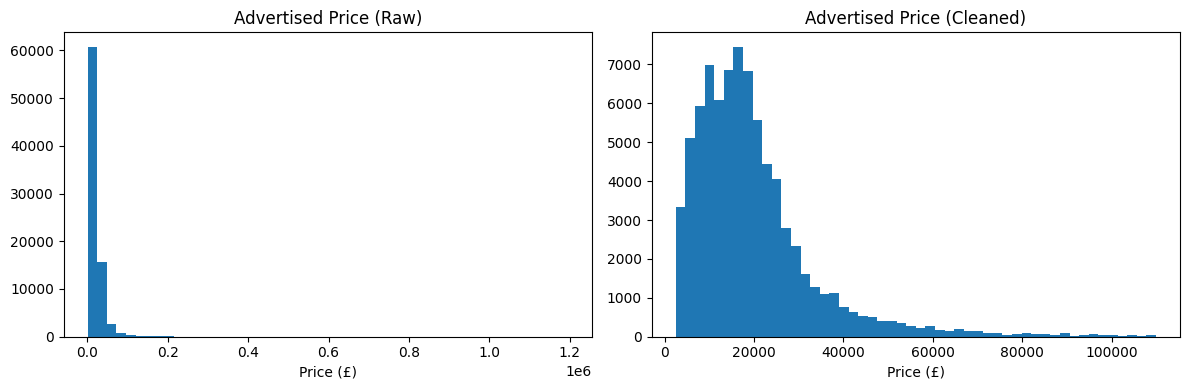

In [74]:
# Compare advertised_price distribution BEFORE and AFTER outlier removal
# This visually confirms the 1st/99th percentile trimming worked as intended

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw price distribution (includes the extreme outliers, e.g. the £1.195m listing)
axes[0].hist(df_raw["advertised_price"], bins=50)
axes[0].set_title("Advertised Price (Raw)")
axes[0].set_xlabel("Price (£)")

# Clean price distribution (outliers trimmed)
axes[1].hist(df_clean["advertised_price"], bins=50)
axes[1].set_title("Advertised Price (Cleaned)")
axes[1].set_xlabel("Price (£)")

plt.tight_layout()
plt.show()


In [ ]:
# For each high-cardinality column, count how many categories have very few
# listings. This matters directly for encoders like Target and CatBoost
# encoding, which compute a statistic (e.g. mean price) per category -
# categories with only a handful of examples produce noisy, unreliable
# statistics and are prone to overfitting if not handled with smoothing
# or grouping into an "Other" bucket.
for col in ["model", "generation", "trim", "make"]:
    counts = df_clean[col].value_counts()
    
    # Categories appearing fewer than 5 times total
    rare_5 = (counts < 5).sum()
    # Categories appearing only once (the most extreme case)
    rare_1 = (counts == 1).sum()
    
    print(f"{col}: {len(counts)} total categories | "
          f"{rare_5} appear fewer than 5 times | "
          f"{rare_1} appear only once")

model: 634 total categories | 126 appear fewer than 5 times | 52 appear only once
generation: 811 total categories | 214 appear fewer than 5 times | 87 appear only once
trim: 1441 total categories | 649 appear fewer than 5 times | 267 appear only once
make: 61 total categories | 12 appear fewer than 5 times | 5 appear only once


In [ ]:
for col in ["model", "generation", "trim", "make"]:
    counts = df_clean[col].value_counts()
    print(f"{col}: min={counts.min()}, max={counts.max()}, median={counts.median()}")

model: min=1, max=2512, median=33.0
generation: min=1, max=3340, median=16.0
trim: min=1, max=3995, median=6.0
make: min=1, max=7307, median=220.0


In [75]:
# Compare summary statistics before and after outlier removal
print("RAW price stats:")
print(df_raw["advertised_price"].describe())
print("\nCLEAN price stats:")
print(df_clean["advertised_price"].describe())


RAW price stats:
count      80,765.00
mean       21,270.82
std        22,805.72
min           695.00
25%        10,495.00
50%        16,990.00
75%        24,499.00
max     1,195,000.00
Name: advertised_price, dtype: float64

CLEAN price stats:
count    79,162.00
mean     19,844.49
std      14,063.00
min       2,499.00
25%      10,679.00
50%      16,990.00
75%      24,250.00
max     109,950.00
Name: advertised_price, dtype: float64


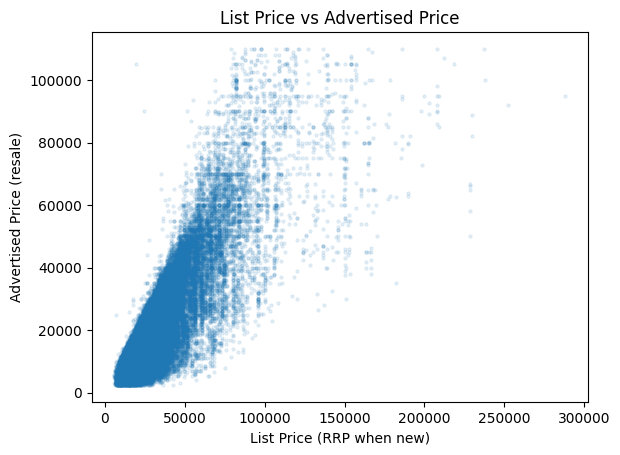

In [76]:
# Check the relationship between list_price (manufacturer RRP when new) and
# advertised_price (resale price). Expect a positive relationship: cars with
# a higher original RRP should generally resell for more.
plt.scatter(df_clean["list_price"], df_clean["advertised_price"], alpha=0.1, s=5)
plt.xlabel("List Price (RRP when new)")
plt.ylabel("Advertised Price (resale)")
plt.title("List Price vs Advertised Price")
plt.show()


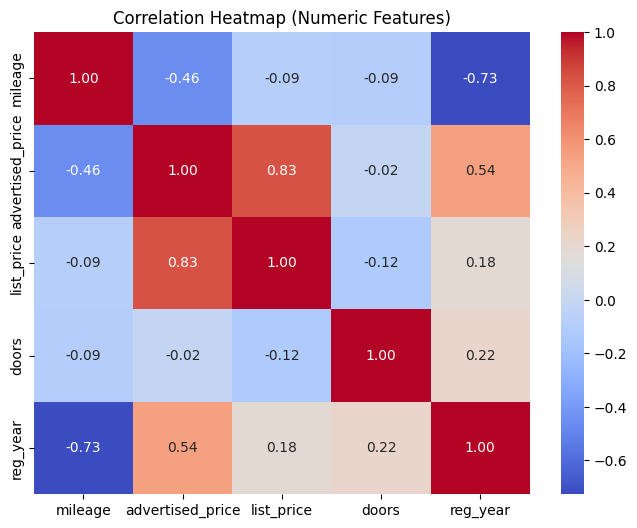

In [77]:
# Correlation heatmap of numeric features on the cleaned data
# Helps spot redundancy (e.g. list_price and advertised_price being highly
# correlated) and relationships worth being aware of before modelling
numeric_cols = ["mileage", "advertised_price", "list_price", "doors", "reg_year"]
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


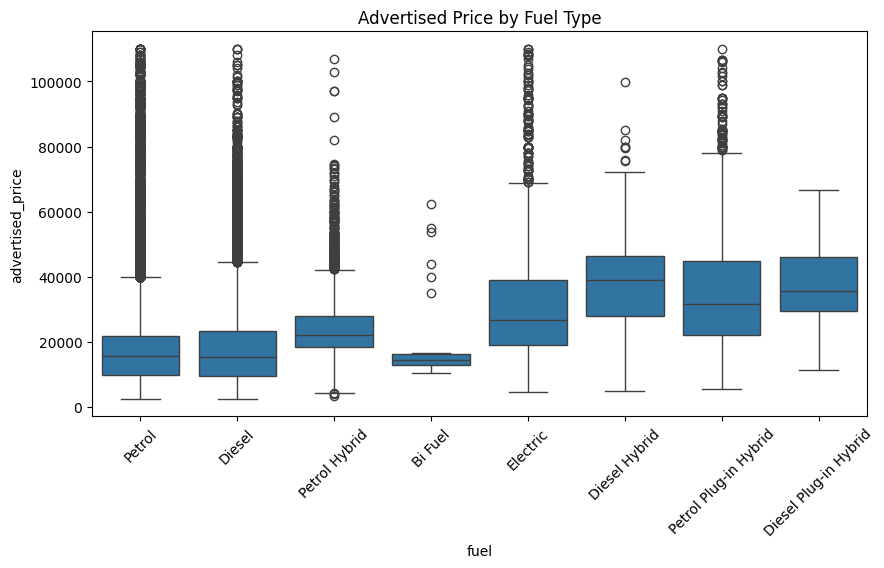

In [78]:
# Boxplot of advertised_price broken down by fuel type
# Sanity-checks that categorical variables visibly relate to price as expected
# (e.g. electric/hybrid vehicles often skew toward different price ranges)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x="fuel", y="advertised_price")
plt.xticks(rotation=45)
plt.title("Advertised Price by Fuel Type")
plt.show()
